# **Machine Learning Workflow**

## Objective

The objective of this notebook is to develop, evaluate, tune, and persist machine learning models for predicting delivery time performance.

---

## Key Goals

- Prepare ML-ready datasets
- Build preprocessing pipelines
- Train baseline regression models
- Compare model performance
- Perform hyperparameter tuning
- Track experiments using MLflow
- Persist the best-performing model

In [1]:
gold_df = spark.read.parquet(
    "Files/gold/featured_delivery_data"
)

display(gold_df)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 3, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, aa50283d-c700-4e29-818a-88afb6daf58f)

In [2]:
pdf = gold_df.toPandas()

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 4, Finished, Available, Finished, False)

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import mlflow
import mlflow.sklearn

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 5, Finished, Available, Finished, False)

## **Feature Selection & Cleanup**

This section removes identifiers, raw datetime columns, and geographic coordinates that are no longer required for machine learning training.

In [4]:
pdf = pdf.drop(
    columns=[

        # IDs
        "Order_ID",

        # Raw datetime columns
        "Order_Date",
        "Order_Time",
        "Pickup_Time",

        # Raw coordinates
        "Store_Latitude",
        "Store_Longitude",
        "Drop_Latitude",
        "Drop_Longitude"
    ],
    errors="ignore"
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 6, Finished, Available, Finished, False)

Feature Engineering Insight

Operationally engineered features such as distance, rush-hour indicators, and weekend flags are retained for predictive modeling.

## **Feature & Target Separation**

In [5]:
X = pdf.drop("Delivery_Time", axis=1)

y = pdf["Delivery_Time"]

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 7, Finished, Available, Finished, False)

##  **Feature Type Identification**

Categorical and numerical features are identified for preprocessing and transformation workflows.

In [6]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", categorical_cols)

print("Numerical:", numerical_cols)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 8, Finished, Available, Finished, False)

Categorical: ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category', 'day_of_week']
Numerical: ['Agent_Age', 'Agent_Rating', 'Distance_km', 'order_hour', 'pickup_hour', 'is_weekend', 'is_rush_hour']


## **Preprocessing Pipeline**
Numerical variables are standardized while categorical variables are one-hot encoded for machine learning compatibility.

In [7]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_cols
        ),

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 9, Finished, Available, Finished, False)

## **Train-Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 10, Finished, Available, Finished, False)

## **Baseline Model Initialization**

Multiple regression models are initialized to establish baseline predictive performance.

In [9]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 11, Finished, Available, Finished, False)

## **MLflow Experiment Tracking**

MLflow is used to track model metrics, parameters, and experiment runs.

In [10]:
mlflow.set_experiment(
    "Amazon_Delivery_Time_Prediction"
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 12, Finished, Available, Finished, False)

<Experiment: artifact_location='sds://onelakecentralindia.pbidedicated.windows.net/f3654803-0ae2-46c6-b5e3-bf931741cfac/43ccb8a7-cfab-4250-b73d-3bd695eb3243', creation_time=1778443762843, experiment_id='43ccb8a7-cfab-4250-b73d-3bd695eb3243', last_update_time=1778443762843, lifecycle_stage='active', name='Amazon_Delivery_Time_Prediction', tags={}>

## **Baseline Model Training & Evaluation**

In [11]:
results = []

for model_name, model in models.items():

    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        mlflow.sklearn.log_model(
            pipeline,
            model_name
        )

        results.append({
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

        print(f"{model_name} completed")

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 13, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Linear Regression completed


Random Forest completed


Gradient Boosting completed


In [12]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 14, Finished, Available, Finished, False)

,Model,MAE,RMSE,R2
1,Random Forest,17.280893,22.584436,0.810878
2,Gradient Boosting,19.492864,24.848954,0.771051
0,Linear Regression,26.266753,33.358836,0.587386


Baseline Modeling Insight

Ensemble-based models demonstrated stronger predictive capability compared to linear regression approaches.

## **Baseline Model Comparison**

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 15, Finished, Available, Finished, False)

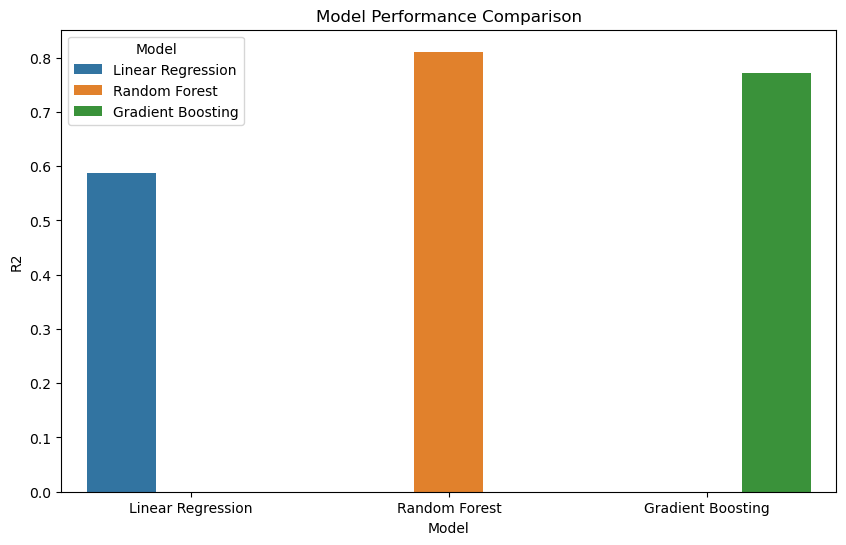

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2",
    data=results_df,
    hue="Model"
)

plt.title("Model Performance Comparison")

plt.savefig(
    "/lakehouse/default/Files/screenshots/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

### Best Baseline Model Selection

In [14]:
best_model_name = results_df.sort_values(
    by="R2",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 16, Finished, Available, Finished, False)

Best Model: Random Forest


In [15]:
best_pipeline = pipeline

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 17, Finished, Available, Finished, False)

In [16]:
import joblib

joblib.dump(
    best_pipeline,
    "/tmp/best_delivery_model_before_tuning.pkl"
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 18, Finished, Available, Finished, False)

['/tmp/best_delivery_model_before_tuning.pkl']

In [17]:
X.columns.tolist()

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 19, Finished, Available, Finished, False)

['Agent_Age',
 'Agent_Rating',
 'Weather',
 'Traffic',
 'Vehicle',
 'Area',
 'Category',
 'Distance_km',
 'order_hour',
 'pickup_hour',
 'day_of_week',
 'is_weekend',
 'is_rush_hour']

### **Hyperparameter Tuning — Random Forest**

RandomizedSearchCV is used to optimize Random Forest hyperparameters for improved predictive performance.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 20, Finished, Available, Finished, False)

In [19]:

rf_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

param_grid = {

    "model__n_estimators": [50, 100, 200],

    "model__max_depth": [5, 10, 20, None],

    "model__min_samples_split": [2, 5, 10],

    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=param_grid,

    n_iter=10,

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

random_search.fit(
    X_train,
    y_train
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 21, Finished, Available, Finished, False)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__max_depth=5, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time=   7.0s
[CV] END model__max_depth=5, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time=   7.3s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   7.3s
[CV] END model__max_depth=5, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time=   7.1s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   7.0s
[CV] END model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   6.7s
[CV] END model__max_depth=20, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=200; total time= 3.1min
[CV] END model__max_depth=20, model__min_s

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Agent_Age',
                                                                                'Agent_Rating',
                                                                                'Distance_km',
                                                                                'order_hour',
                                                                                'pickup_hour',
                                                                                'is_weekend',
                                                                                'is_rush_hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Weather',
                                                                                'Traffic',
                                                                                'Vehicle',
                                                                                'Area',
                                                                                'Category',
                                                                                'day_of_week'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 20, None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [50, 100, 200]},
                   random_state=42, verbose=2)

In [20]:
print("Best Parameters:")

print(random_search.best_params_)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 22, Finished, Available, Finished, False)

Best Parameters:
{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 10}


In [21]:
best_rf = random_search.best_estimator_

predictions = best_rf.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 23, Finished, Available, Finished, False)

MAE: 16.894549369352625
RMSE: 21.87509571024364
R2: 0.8225718284778039


 Random Forest Tuning Insight

Hyperparameter tuning improved the model’s ability to capture nonlinear operational delivery patterns.

### **Hyperparameter Tuning — Gradient Boosting**

Gradient Boosting hyperparameters are optimized to improve predictive robustness and delivery time estimation accuracy.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 24, Finished, Available, Finished, False)

In [23]:
gb_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gb_param_grid = {

    "model__n_estimators": [50, 100, 200],

    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__max_depth": [3, 5, 7],

    "model__min_samples_split": [2, 5, 10],

    "model__min_samples_leaf": [1, 2, 4]
}

gb_random_search = RandomizedSearchCV(

    estimator=gb_pipeline,

    param_distributions=gb_param_grid,

    n_iter=10,

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1
)

gb_random_search.fit(
    X_train,
    y_train
)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 25, Finished, Available, Finished, False)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=50; total time=   1.9s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=50; total time=   1.9s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=50; total time=   1.9s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=50; total time=   2.0s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=50; total time=   2.1s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=50; total time=   2.6s
[CV] END 

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Agent_Age',
                                                                                'Agent_Rating',
                                                                                'Distance_km',
                                                                                'order_hour',
                                                                                'pickup_hour',
                                                                                'is_weekend',
                                                                                'is_rush_hour']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['Weather',
                                                                                'Traffic',
                                                                                'Vehicle',
                                                                                'Area',
                                                                                'Category',
                                                                                'day_of_week'])])),
                                             ('model',
                                              GradientBoostingRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [50, 100, 200]},
                   random_state=42, verbose=2)

In [24]:
print("Best Gradient Boosting Parameters:")

print(gb_random_search.best_params_)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 26, Finished, Available, Finished, False)

Best Gradient Boosting Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 7, 'model__learning_rate': 0.05}


In [25]:
best_gb = gb_random_search.best_estimator_

gb_predictions = best_gb.predict(X_test)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2:", gb_r2)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 27, Finished, Available, Finished, False)

Gradient Boosting MAE: 17.028528430021392
Gradient Boosting RMSE: 21.885019740560885
Gradient Boosting R2: 0.8224108050028431


### Gradient Boosting Tuning Insight

Gradient Boosting demonstrated strong predictive performance across operational delivery conditions.

## **Tuned Model Performance Summary**

In [26]:
tuned_results = pd.DataFrame({

    "Model": [

        "Tuned Random Forest",

        "Tuned Gradient Boosting"
    ],

    "MAE": [

        mae,
        gb_mae
    ],

    "RMSE": [

        rmse,
        gb_rmse
    ],

    "R2": [

        r2,
        gb_r2
    ]
})

tuned_results

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 28, Finished, Available, Finished, False)

,Model,MAE,RMSE,R2
0,Tuned Random Forest,16.894549,21.875096,0.822572
1,Tuned Gradient Boosting,17.028528,21.885020,0.822411


### **Before vs After Tuning Analysis**

In [27]:
final_results = pd.concat(
    [
        results_df,
        tuned_results
    ],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="R2",
    ascending=False
)

final_results

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 29, Finished, Available, Finished, False)

,Model,MAE,RMSE,R2
3,Tuned Random Forest,16.894549,21.875096,0.822572
4,Tuned Gradient Boosting,17.028528,21.885020,0.822411
1,Random Forest,17.280893,22.584436,0.810878
2,Gradient Boosting,19.492864,24.848954,0.771051
0,Linear Regression,26.266753,33.358836,0.587386


StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 30, Finished, Available, Finished, False)

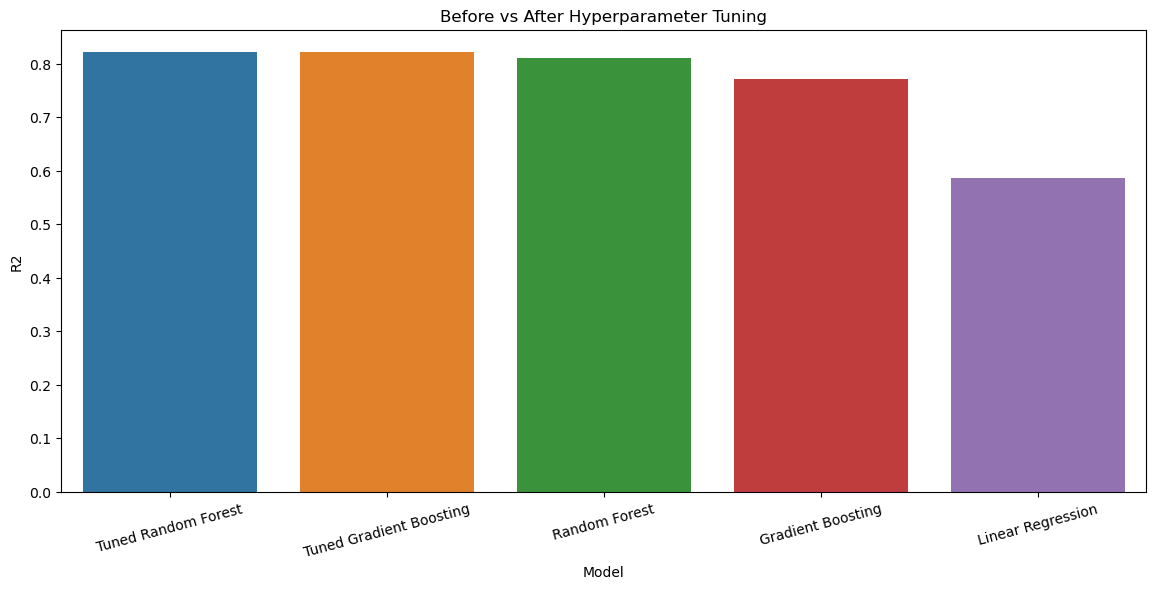

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="R2"
)

plt.title(
    "Before vs After Hyperparameter Tuning"
)

plt.xticks(rotation=15)

plt.savefig(
    "/lakehouse/default/Files/screenshots/before_after_tuning.png",
    bbox_inches="tight"
)

plt.show()

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 31, Finished, Available, Finished, False)

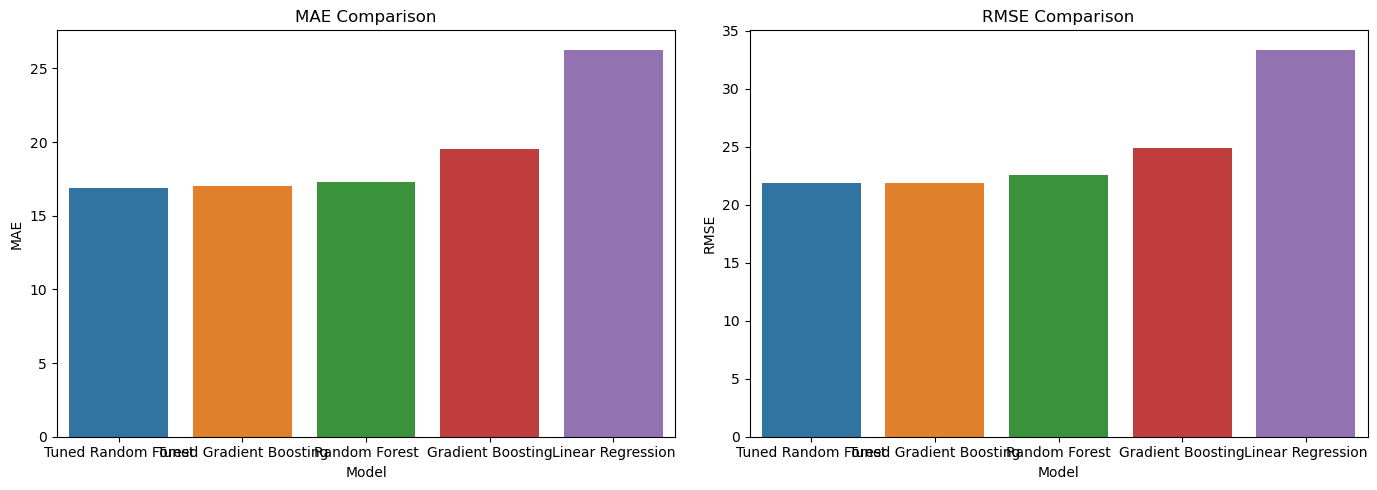

In [29]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

sns.barplot(
    data=final_results,
    x="Model",
    y="MAE",
    ax=axes[0]
)

axes[0].set_title("MAE Comparison")

sns.barplot(
    data=final_results,
    x="Model",
    y="RMSE",
    ax=axes[1]
)

axes[1].set_title("RMSE Comparison")

plt.tight_layout()

plt.savefig(
    "/lakehouse/default/Files/screenshots/error_metrics_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
best_model_row = final_results.iloc[0]

print("Best Model:")

print(best_model_row)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 32, Finished, Available, Finished, False)

Best Model:
Model    Tuned Random Forest
MAE                16.894549
RMSE               21.875096
R2                  0.822572
Name: 3, dtype: object


### **Final Model Persistence**

The best-performing tuned model is persisted for deployment and Streamlit integration.

In [31]:
import joblib
import shutil

# Select best model

if best_model_row["Model"] == "Tuned Random Forest":

    final_model = best_rf

elif best_model_row["Model"] == "Tuned Gradient Boosting":

    final_model = best_gb

else:

    final_model = best_pipeline

# Save locally first

joblib.dump(
    final_model,
    "/tmp/best_delivery_model_after_tuning.pkl"
)

# Copy into Lakehouse

shutil.copy(

    "/tmp/best_delivery_model_after_tuning.pkl",

    "/lakehouse/default/Files/models/best_delivery_model_after_tuning.pkl"
)

print("Best model saved successfully.")

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 33, Finished, Available, Finished, False)

Best model saved successfully.


In [32]:
import os

os.listdir("/lakehouse/default/Files/models")

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 34, Finished, Available, Finished, False)

['best_delivery_model_after_tuning.pkl']

In [35]:
import sys
import sklearn
import numpy
import pandas
import joblib

print("Python Version:", sys.version)
print("Scikit-learn Version:", sklearn.__version__)
print("NumPy Version:", numpy.__version__)
print("Pandas Version:", pandas.__version__)
print("Joblib Version:", joblib.__version__)

StatementMeta(, baf7e908-f34f-45fa-971a-86ca516e6124, 38, Finished, Available, Finished, False)

Python Version: 3.11.8 (main, Feb 26 2024, 21:39:34) [GCC 11.2.0]
Scikit-learn Version: 1.2.2
NumPy Version: 1.26.4
Pandas Version: 2.1.4
Joblib Version: 1.2.0


# <u>**Final Machine Learning Insights**</u>

- Ensemble-based models significantly outperformed Linear Regression.
- Gradient Boosting and Random Forest effectively captured nonlinear delivery patterns.
- Distance, traffic conditions, and rush-hour indicators emerged as major predictive contributors.
- Hyperparameter tuning improved model robustness and predictive performance.
- Operationally engineered features enhanced predictive capability.

---

# **<u>Next Steps</u>**

The persisted best-performing model will be used for:
- Streamlit deployment
- real-time delivery prediction
- operational analytics
- future model monitoring workflows